In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook EnMAP - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [3]:
import sys

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

from kneed import KneeLocator

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import xml.etree.ElementTree as ET

import re

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the EnMAP image and display them.

In [1]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the soil:

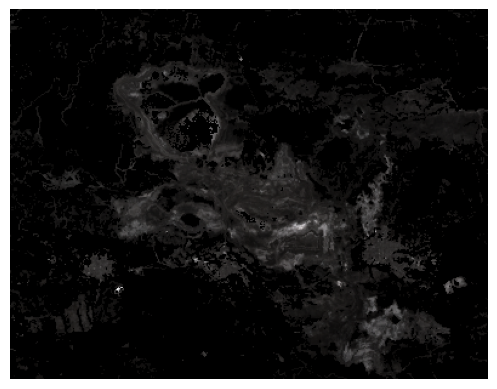

In [5]:
soil_only, fond_soil = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                       r"./INSA_cropped_2_EnMAP_20240508_mask_SOIL_SAVI_DSBI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

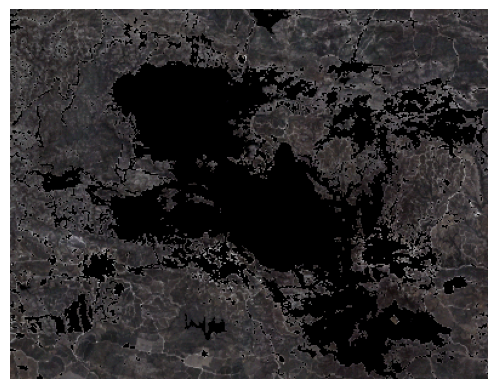

In [6]:
vegetation_only, fond_vegetation = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                             r"./INSA_cropped_2_EnMAP_20240508_mask_NDVI.tiff")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [7]:
image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation

In [7]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

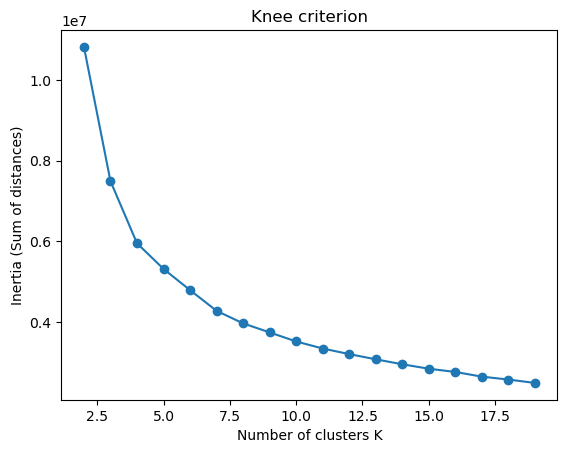

optimal value: k = 7


In [8]:
optimal_k_veg = compute_optimal_k(X_scaled_veg)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We use the function extract_wavelengths_from_auxxml to get the number of wavelengths and their values.

In [12]:
def extract_wavelengths_from_auxxml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    wavelengths = []

    # Pour chaque bande dans l'ordre
    for band in root.findall(".//PAMRasterBand"):
        desc = band.find("Description")
        if desc is not None and desc.text:
            match = re.search(r"\(([\d.]+)\s*Nanometers\)", desc.text)
            if match:
                wl = float(match.group(1))
                wavelengths.append(wl)

    return wavelengths

In [13]:
xml_file = r"./INSA_cropped_2_EnMAP_20240508.tif.aux.xml"
wavelengths = extract_wavelengths_from_auxxml(xml_file)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score as well as the Calinski-Harabasz Index.

In [11]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, wavelengths, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_scaled, labels)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    print(f"Calinski-Harabasz for k = {optimal_k} : {ch_score:.2f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = wavelengths
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 7 : 0.269
Calinski-Harabasz for k = 7 : 40269.48


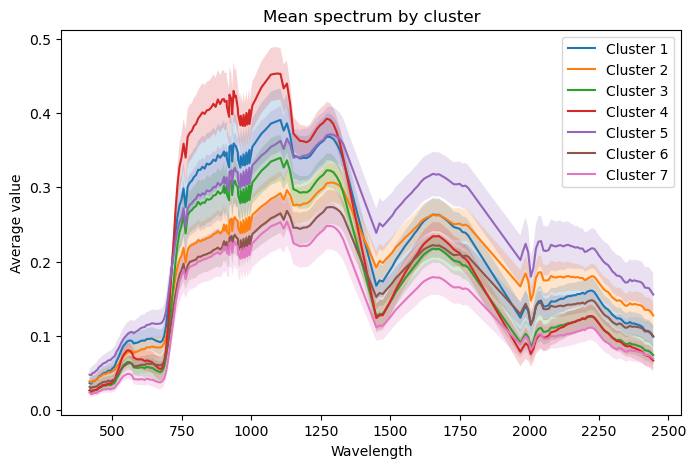

In [12]:
labels_veg = KMeans_mean_spectra(X_scaled_veg, veg_mask_1d, optimal_k_veg, l, wavelengths)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [13]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

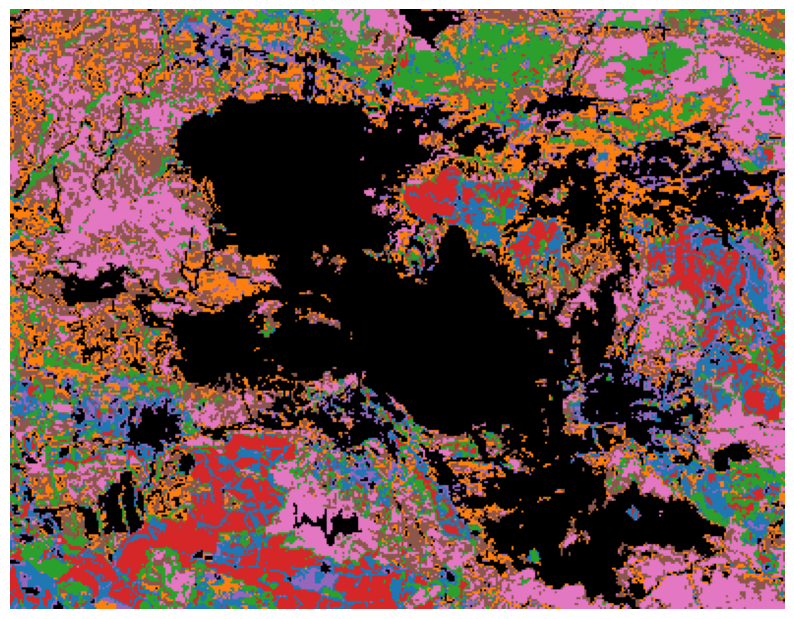

In [14]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [8]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


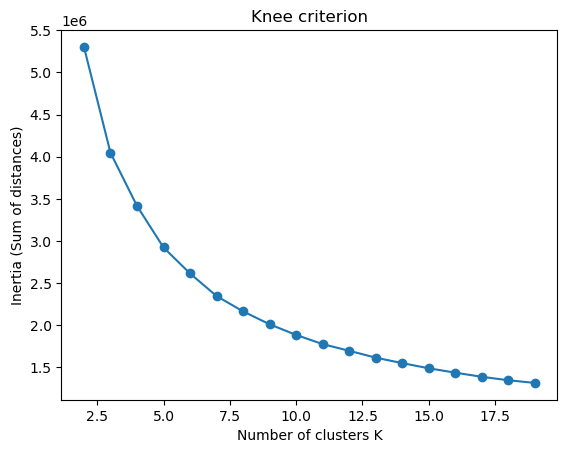

optimal value: k = 7


In [16]:
optimal_k_soil = compute_optimal_k(X_scaled_soil)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 30 instead. 

In [17]:
optimal_k_soil = 30

Silhouette (sampled) for k = 30 : 0.188
Calinski-Harabasz for k = 30 : 10426.58


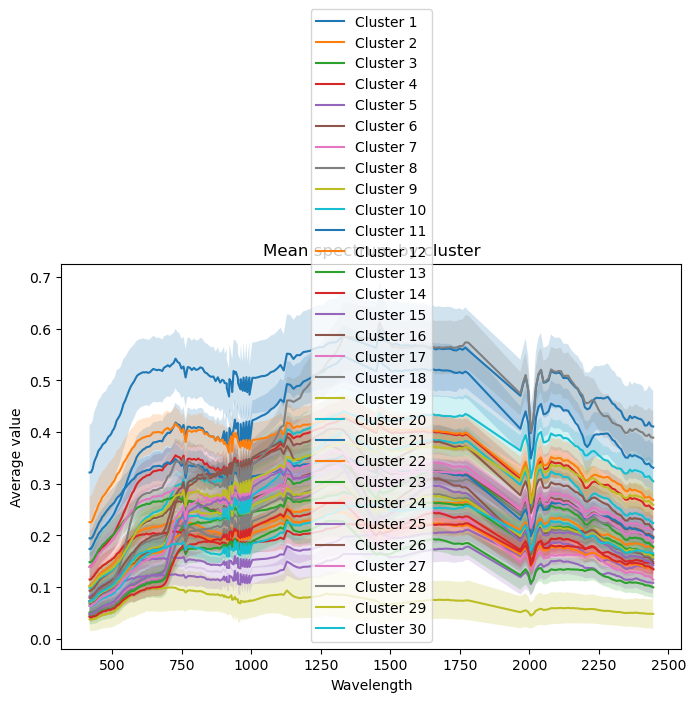

In [18]:
labels_soil = KMeans_mean_spectra(X_scaled_soil, soil_mask_1d, optimal_k_soil, l, wavelengths)

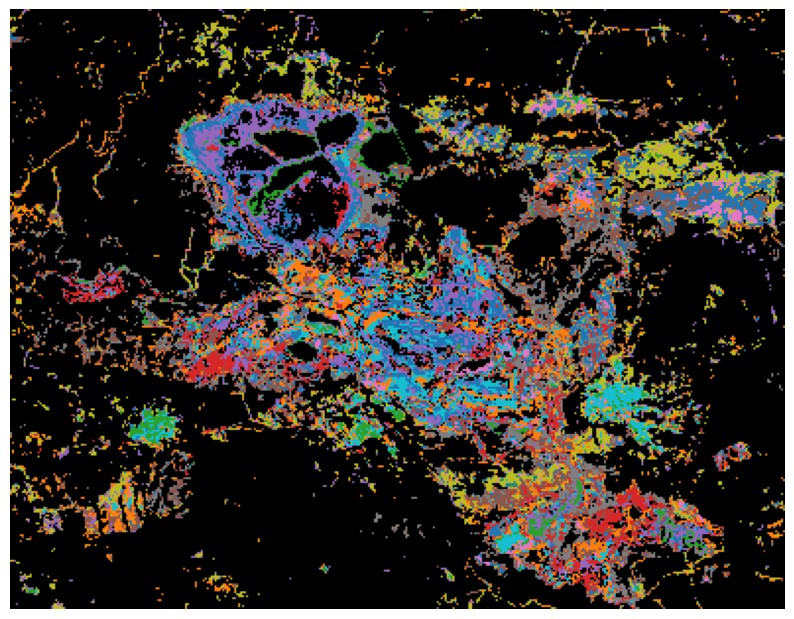

In [19]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [9]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

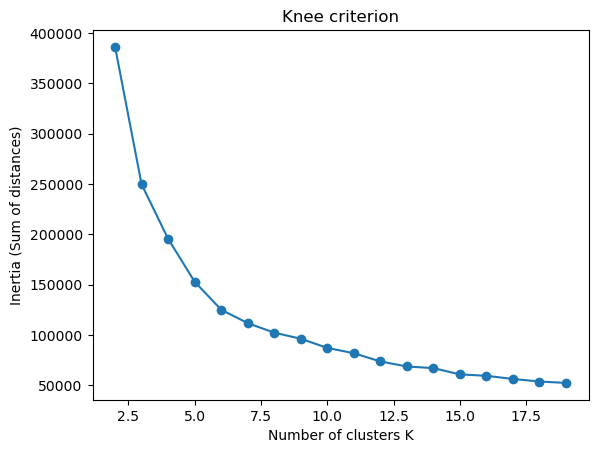

optimal value: k = 6


In [21]:
optimal_k_other = compute_optimal_k(X_scaled_other)

Silhouette (sampled) for k = 6 : 0.481
Calinski-Harabasz for k = 6 : 9139.12


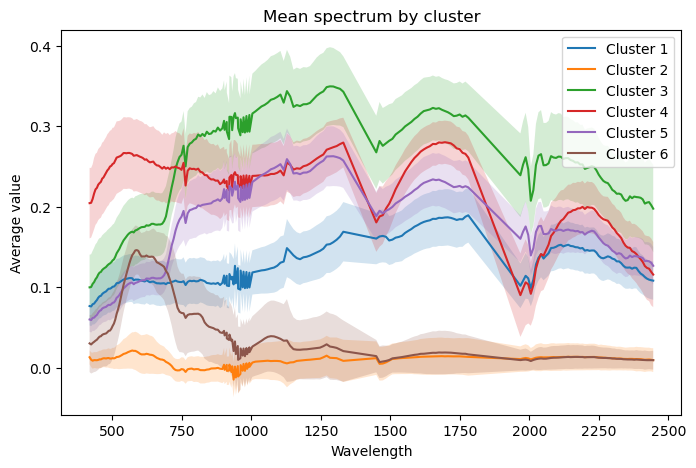

In [22]:
labels_other = KMeans_mean_spectra(X_scaled_other, other_mask_1d, optimal_k_other, l, wavelengths)

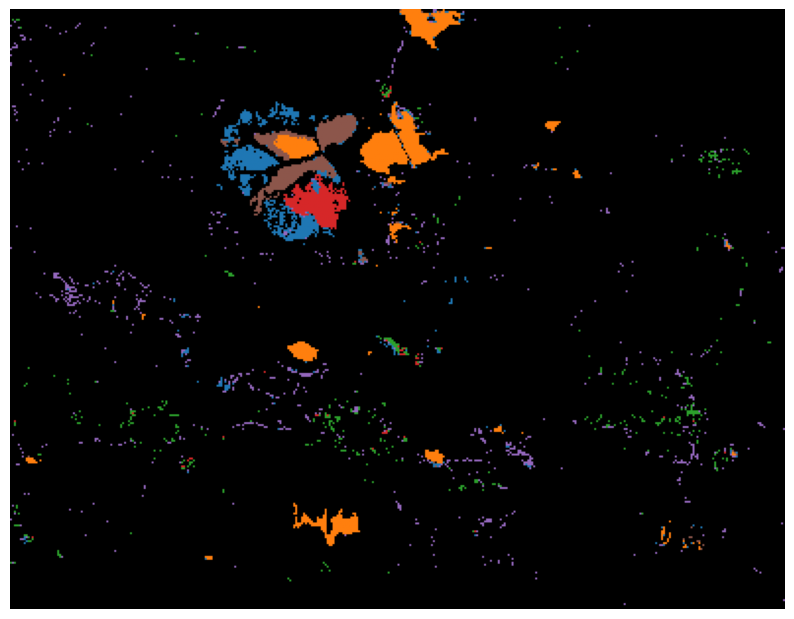

In [23]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [24]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(256, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(256, 512),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(512, in_dim),
            nn.Sigmoid() # Pour s'assurer que les pixels sont entre 0 et 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [25]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [26]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples=10000):

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    n_samples = X_scaled.shape[0]

    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels_1d[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels_1d

    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_sampled, labels_sampled)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")
    print(f"Calinski-Harabasz pour k = {n_clusters} : {ch_score:.2f}")

In [27]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation

In [28]:
train_PbP_autoencoder(16, 5, X_scaled_veg, optimal_k_veg)

Epoch 1/5   Loss = 0.576352
Epoch 2/5   Loss = 0.543991
Epoch 3/5   Loss = 0.542684
Epoch 4/5   Loss = 0.541105
Epoch 5/5   Loss = 0.540364
Silhouette (échantillon) pour k = 7 : 0.268
Calinski-Harabasz pour k = 7 : 4936.71


<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [29]:
train_PbP_autoencoder(16, 5, X_scaled_soil, optimal_k_soil)

Epoch 1/5   Loss = 0.656201
Epoch 2/5   Loss = 0.590186
Epoch 3/5   Loss = 0.585702
Epoch 4/5   Loss = 0.583024
Epoch 5/5   Loss = 0.581512
Silhouette (échantillon) pour k = 30 : 0.148
Calinski-Harabasz pour k = 30 : 2263.52


<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [30]:
train_PbP_autoencoder(16, 5, X_scaled_other, optimal_k_other)

Epoch 1/5   Loss = 0.792797
Epoch 2/5   Loss = 0.581073
Epoch 3/5   Loss = 0.566978
Epoch 4/5   Loss = 0.556476
Epoch 5/5   Loss = 0.555088
Silhouette (échantillon) pour k = 6 : 0.358
Calinski-Harabasz pour k = 6 : 5011.62


<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [47]:
LATENT_DIM = 16
EPOCHS = 5
PATCH_SIZE = 16
STRIDE = 1
BATCH_SIZE = 256
MAX_SAMPLES = 10000

In [49]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=1, padding=1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),          # H/8
            nn.ReLU(True)
        )
        
        # Pas besoin de input_size fixe : taille après conv dépend du patch
        self.fc_enc = None  # on initialisera dynamiquement au premier forward
        self.fc_dec = None

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride= 1, padding=1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3,stride= 1, padding=1),    # H*2
            nn.Sigmoid()
        )

        self.latent_dim = latent_dim
        self._fc_initialized = False

    def _init_fc(self, x):
        # Calculer la taille de flatten après encoder pour ce patch
        with torch.no_grad():
            z = self.encoder_conv(x)
            batch_size, c, h, w = z.size()
            
            # --- CORRECTION ICI ---
            # On crée la couche ET on l'envoie immédiatement sur le device de x (le GPU)
            self.fc_enc = nn.Linear(c*h*w, self.latent_dim).to(x.device)
            self.fc_dec = nn.Linear(self.latent_dim, c*h*w).to(x.device)
            # ----------------------
            
        self._fc_initialized = True

    def forward(self, x):
        if not self._fc_initialized:
            self._init_fc(x)
        # Encoder
        z = self.encoder_conv(x)
        batch_size, c, h, w = z.size()
        z_flat = z.view(batch_size, -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(batch_size, c, h, w)  # reshape exactement aux dimensions du conv
        x_recon = self.decoder_conv(z_dec)
        return x_recon, z_latent
    
    def encode(self, x):
        latent_map = self.encoder_conv(x)
        latent = latent_map.view(latent_map.size(0), -1)
        return latent

In [68]:
def extract_valid_patches_with_mask(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, min_fraction=0.8):
    """
    Extrait des patchs valides selon un masque.
    
    image : [C,H,W]
    mask  : [H,W] ou [1,H,W], bool ou 0/1
    """
    if mask.dim() == 3:
        mask = mask[0]  # si mask [1,H,W]
    
    C, H, W = image.shape
    patches = []
    positions = []

    for i in range(0, H-patch_size+1, stride):
        for j in range(0, W-patch_size+1, stride):
            patch_mask = mask[i:i+patch_size, j:j+patch_size].bool()
            valid_fraction = patch_mask.float().mean().item()
            if valid_fraction >= min_fraction:
                num_valid_pixels = patch_mask.sum()
                patch = image[:, i:i+patch_size, j:j+patch_size]
                extended_mask = patch_mask.unsqueeze(0).expand_as(patch)
                valid_pixels = patch[extended_mask]
                valid_pixels = valid_pixels.view(C, -1)
                sum_valid_per_channel = valid_pixels.sum(dim=1)
                mean_valid_per_channel = sum_valid_per_channel / num_valid_pixels
                invalid_mask = ~extended_mask
                for c in range(C):
                    patch[c][invalid_mask[c]] = mean_valid_per_channel[c]
                patches.append(patch.unsqueeze(0))
                positions.append((i,j))
    
    if len(patches) > 0:
        patch_tensor = torch.cat(patches, dim=0)
    else:
        patch_tensor = torch.empty(0, C, patch_size, patch_size)
    
    return patch_tensor, positions

In [51]:
def train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_SAMPLES):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    patch_tensor, positions = extract_valid_patches_with_mask(torch.Tensor(img_scaled_complete.T.reshape(l,m,n)), torch.Tensor(mask_2d), PATCH_SIZE, STRIDE)
    print(f"Nombre de patchs valides : {len(patch_tensor)}")
    
    dataset = TensorDataset(patch_tensor)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Paramètres boucle
    total_idx = []
    n_batches = 10
    all_latents = []

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

        # Échantillonnage aléatoire
        dataset_size = len(dataset)
        n_samples = min(n_batches * BATCH_SIZE, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        subset_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        batch_idx = 0
        for batch in loader:
            batch_idx += 1
            x = batch[0].to(DEVICE)
            optimizer.zero_grad()
            out, _ = model(x)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{len(subset_loader)}  Loss: {loss.item():.6f}", end="")
            sys.stdout.flush()

        
        print(f"\nEpoch {ep+1}/{EPOCHS}   Moyenne Loss = {loss_sum/len(subset_loader):.6f}")

    # ----------------------
    # Extraction des latents
    # ----------------------
    model.eval()
    all_latents = []
    with torch.no_grad():
        for batch in DataLoader(patch_tensor, batch_size=BATCH_SIZE, shuffle=False):
            x = batch[0].to(DEVICE)
            latent = model.encode(x)
            all_latents.append(latent.cpu().numpy())
    latent_vectors = np.concatenate(all_latents, axis=0)

    return latent_vectors

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [52]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [53]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [54]:
def KM_Silhouette(latent_vectors, n_clusters):
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels = kmeans.fit_predict(latent_vectors)
    
    sil_score = silhouette_score(latent_vectors, labels)
    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")
    ch_score  = calinski_harabasz_score(latent_vectors, labels)
    print(f"Calinski-Harabasz pour k = {n_clusters} : {ch_score:.2f}")

    return labels

In [69]:
latent_vectors_veg = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_veg, optimal_k_veg, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_veg_complete, veg_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 53438
Epoch 1/5  Batch 210/209  Loss: 0.681603
Epoch 1/5   Moyenne Loss = 0.760785
Epoch 2/5  Batch 210/209  Loss: 0.654438
Epoch 2/5   Moyenne Loss = 0.657678
Epoch 3/5  Batch 210/209  Loss: 0.643410
Epoch 3/5   Moyenne Loss = 0.649151
Epoch 4/5  Batch 210/209  Loss: 0.651324
Epoch 4/5   Moyenne Loss = 0.645483
Epoch 5/5  Batch 210/209  Loss: 0.673478
Epoch 5/5   Moyenne Loss = 0.643044


In [70]:
labels_veg = KM_Silhouette(latent_vectors_veg, optimal_k_veg)

Silhouette (échantillon) pour k = 7 : 0.426
Calinski-Harabasz pour k = 7 : 12038.67


<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [71]:
latent_vectors_soil = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_soil, optimal_k_soil, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_soil_complete, soil_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 18476
Epoch 1/5  Batch 74/73  Loss: 0.877551
Epoch 1/5   Moyenne Loss = 0.968989
Epoch 2/5  Batch 74/73  Loss: 0.796109
Epoch 2/5   Moyenne Loss = 0.803635
Epoch 3/5  Batch 74/73  Loss: 0.652647
Epoch 3/5   Moyenne Loss = 0.749745
Epoch 4/5  Batch 74/73  Loss: 0.830428
Epoch 4/5   Moyenne Loss = 0.731369
Epoch 5/5  Batch 74/73  Loss: 0.853352
Epoch 5/5   Moyenne Loss = 0.725432


In [72]:
labels_soil = KM_Silhouette(latent_vectors_soil, optimal_k_soil)

Silhouette (échantillon) pour k = 30 : 0.299
Calinski-Harabasz pour k = 30 : 1015.87


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [74]:
latent_vectors_other = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_other, optimal_k_other, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_other_complete, other_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 447
Epoch 1/5  Batch 3/2  Loss: 1.495754
Epoch 1/5   Moyenne Loss = 1.538028
Epoch 2/5  Batch 3/2  Loss: 1.358628
Epoch 2/5   Moyenne Loss = 1.458864
Epoch 3/5  Batch 3/2  Loss: 0.986373
Epoch 3/5   Moyenne Loss = 1.093725
Epoch 4/5  Batch 3/2  Loss: 0.923839
Epoch 4/5   Moyenne Loss = 0.933698
Epoch 5/5  Batch 3/2  Loss: 0.934243
Epoch 5/5   Moyenne Loss = 0.942122


In [75]:
labels_other = KM_Silhouette(latent_vectors_other, optimal_k_other)

Silhouette (échantillon) pour k = 6 : 0.803
Calinski-Harabasz pour k = 6 : 3075.22


Nombre de clusters pour la végétation avec CAH

In [10]:
N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]
X_sample_original = veg_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

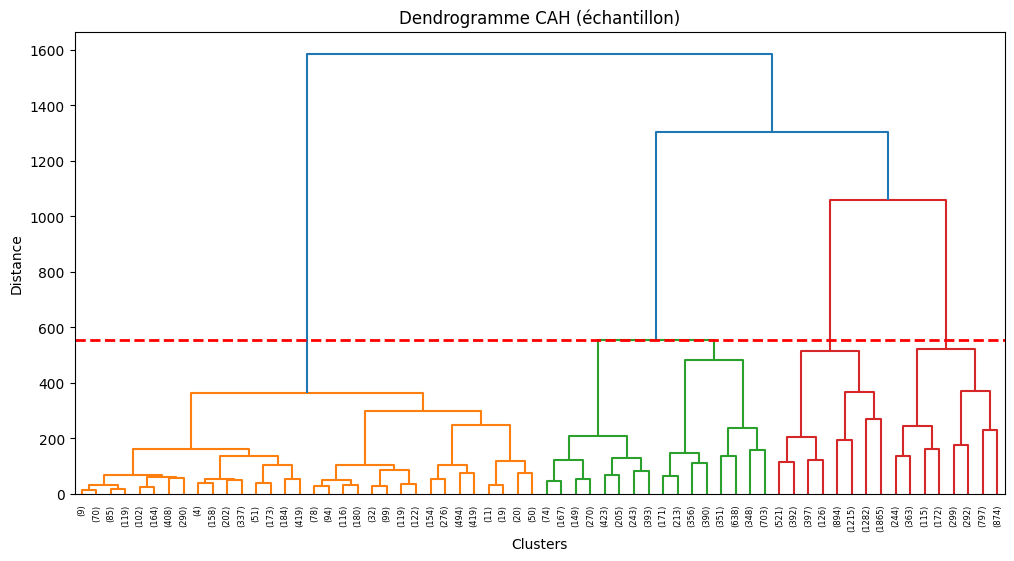

In [11]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

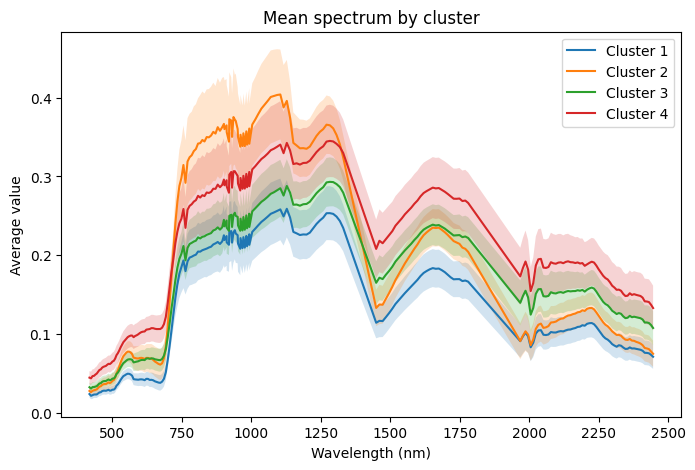

In [14]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Clusters can be associated to different kinds of vegetation which is more or less sane depending on the mean spectrum : a lower reflectance means that the vegetation is less dense/sane while a higher reflectance indicates luxurious vegetation.

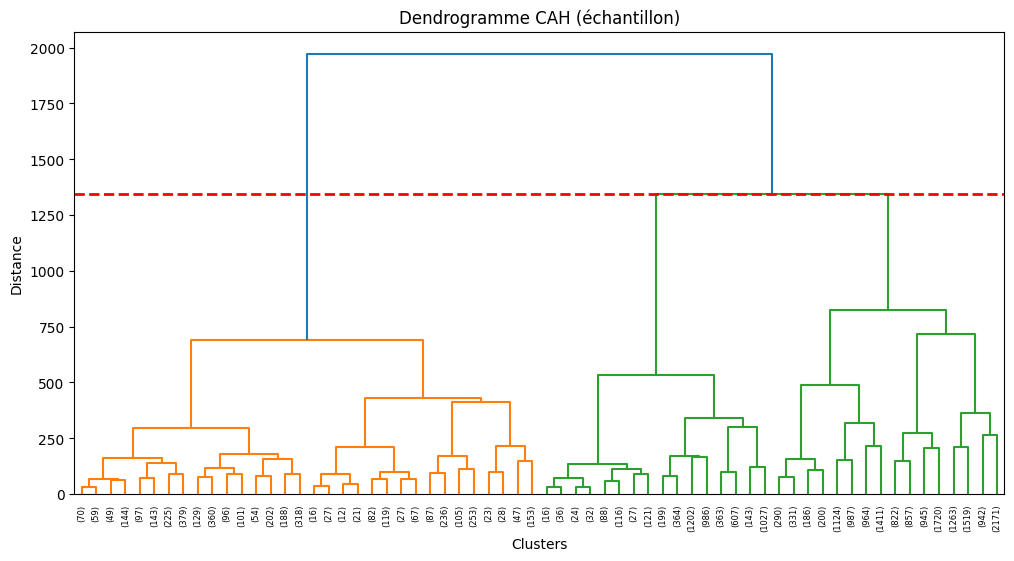

In [16]:
N = 25000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]
X_sample_original = soil_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


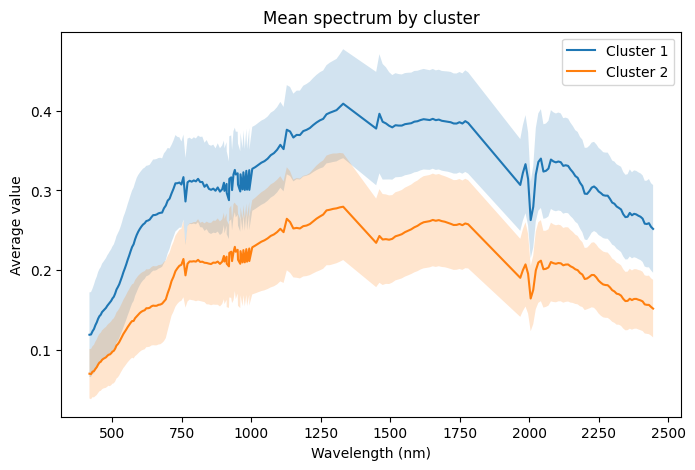

In [17]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the soil. The mean spectrum shows that both clusters have similar shapes, but that cluster one has lower reflectance, which could be due to the presence of water. Thus, we can suggest that cluster one corresponds to wet soils (agricultural soils, loamy soils...) and cluster two to drier soil areas.

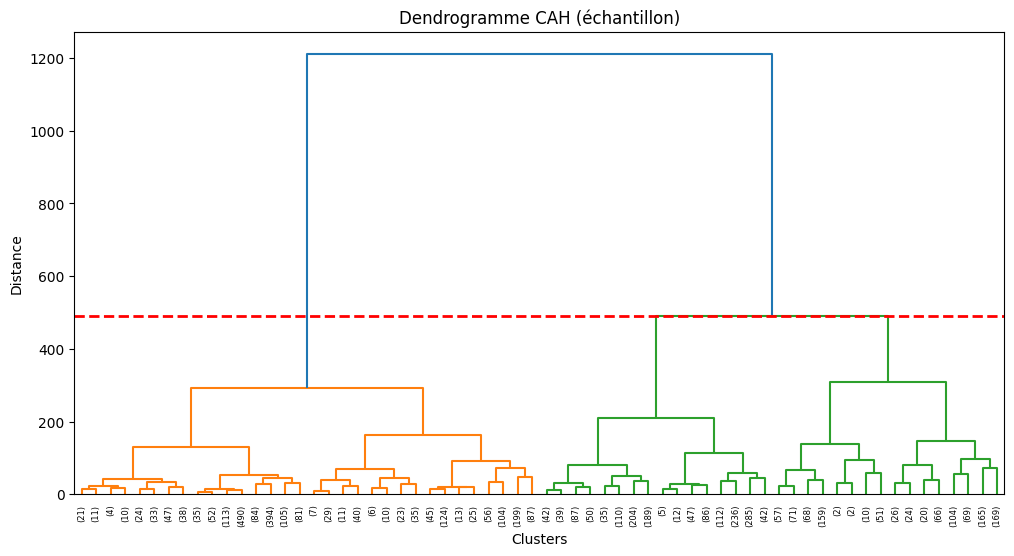

In [23]:
N = 5000
idx = np.random.choice(len(X_scaled_other), N, replace=False)
X_sample = X_scaled_other[idx]
X_sample_original = other_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

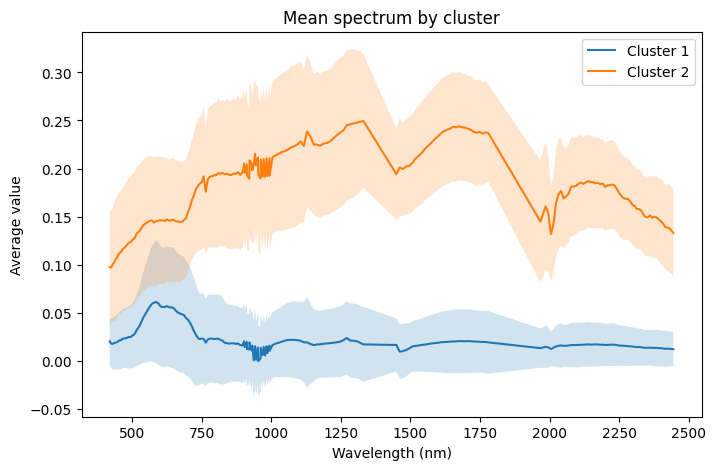

In [24]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = wavelengths

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters for the remaining pixels. Cluster one, with very low reflectance, has a shape that is characteristic of water areas (shallow water). Cluster two has a shape that recalls the spectrum of concrete or similar materials, which could be associated to more urban areas.